# Phishing Email Detection using Machine Learning

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# Use Seaborn's styling
sns.set()

## Load and Preprocess Data

In [2]:
# Load the dataset
df = pd.read_csv('dataset/phishing_email.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (82486, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


## Exploratory Data Analysis

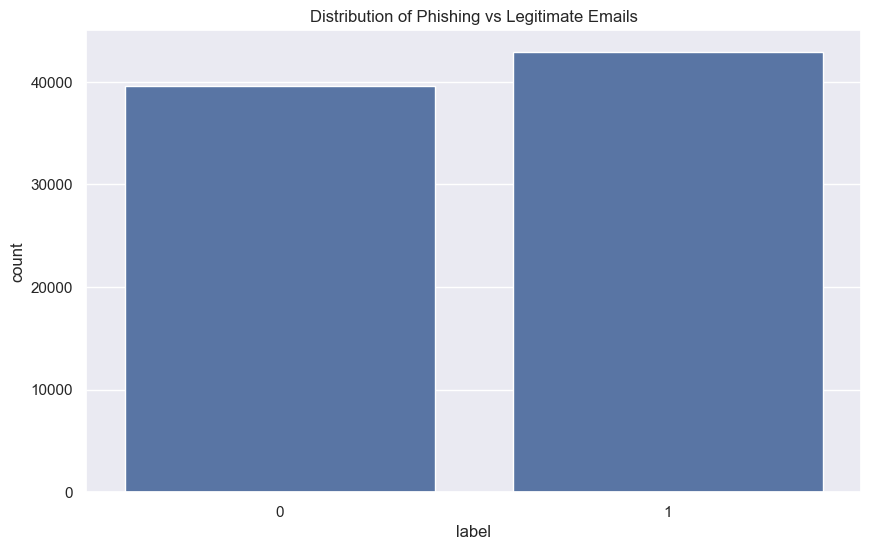


Class Distribution (%):
 label
1    51.997915
0    48.002085
Name: proportion, dtype: float64


In [3]:
# Check class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label')
plt.title('Distribution of Phishing vs Legitimate Emails')
plt.show()

# Calculate class distribution percentages
class_dist = df['label'].value_counts(normalize=True) * 100
print("\nClass Distribution (%):\n", class_dist)

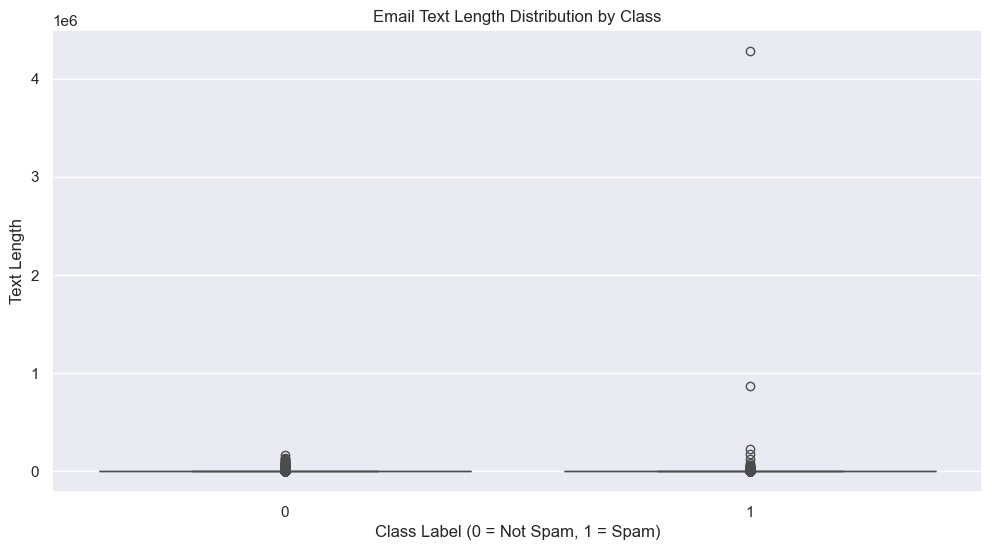

In [4]:
# Text length analysis
df['text_length'] = df['text_combined'].str.len()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='label', y='text_length')
plt.title('Email Text Length Distribution by Class')
plt.xlabel('Class Label (0 = Not Spam, 1 = Spam)')
plt.ylabel('Text Length')
plt.show()

## Feature Engineering and Text Preprocessing

In [5]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['text_combined'])  # ← Fixed column name here

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training and Evaluation

In [6]:
# Initialize models
models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear'),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': accuracy,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }
    print(f"{name} Accuracy: {accuracy:.4f}\n")

Training Naive Bayes...
Naive Bayes Accuracy: 0.9624

Training SVM...
SVM Accuracy: 0.9839

Training Random Forest...
Random Forest Accuracy: 0.9865



## Model Comparison Visualizations

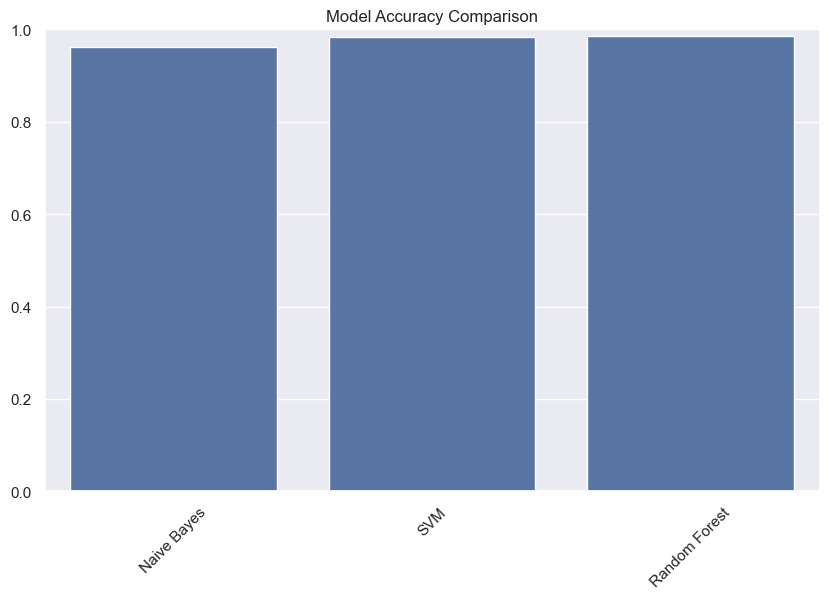

In [7]:
# Accuracy comparison
plt.figure(figsize=(10, 6))
accuracies = [results[model]['accuracy'] for model in models.keys()]
sns.barplot(x=list(models.keys()), y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

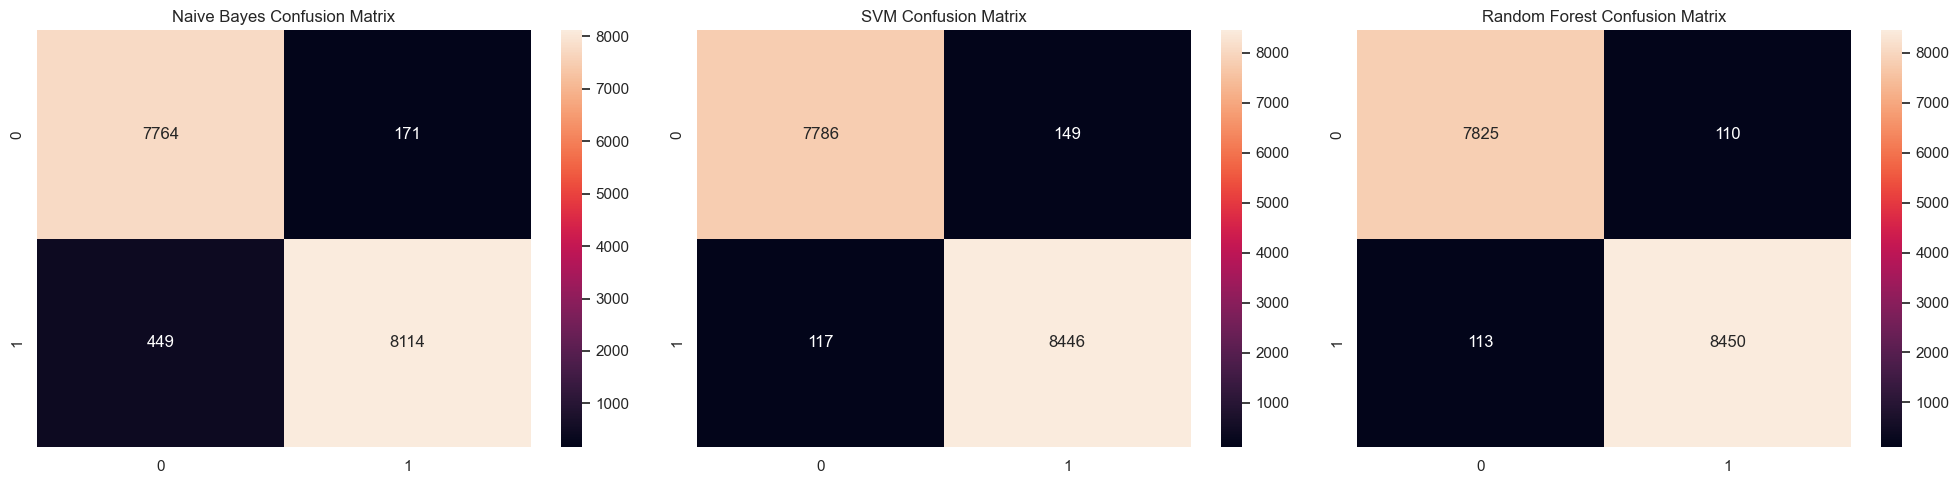

In [8]:
# Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

## Detailed Classification Reports

In [9]:
for name, result in results.items():
    print(f"\n{name} Classification Report:")
    print(result['classification_report'])


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7935
           1       0.98      0.95      0.96      8563

    accuracy                           0.96     16498
   macro avg       0.96      0.96      0.96     16498
weighted avg       0.96      0.96      0.96     16498


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7935
           1       0.98      0.99      0.98      8563

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7935
           1       0.99      0.99      0.99      8563

    accuracy                           0.99     16498
   macro avg       0.99   

## Feature Importance Analysis (for Random Forest)

<Figure size 1200x600 with 0 Axes>

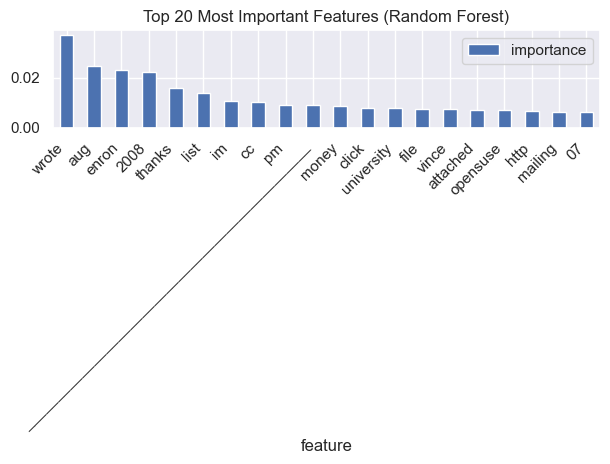

In [10]:
# Get feature importance from Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf_model.feature_importances_
})

# Plot top 20 most important features
plt.figure(figsize=(12, 6))
feature_importance.sort_values('importance', ascending=False).head(20).plot(x='feature', y='importance', kind='bar')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Model Generation and Saving for Web Deployment
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib

def generate_model_for_deployment():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
        ('classifier', LogisticRegression(max_iter=1000))
    ])
    
    print("Training final model for deployment...")
    pipeline.fit(df['text_combined'], df['label'])
    
    print("Saving model pipeline...")
    joblib.dump(pipeline, 'phishing_email_detector.joblib')
    
    print("Testing saved model...")
    test_text = ["Urgent: Your account needs verification. Click here to update your details."]
    loaded_model = joblib.load('phishing_email_detector.joblib')
    prediction = loaded_model.predict(test_text)
    prediction_prob = loaded_model.predict_proba(test_text)
    
    print("\nModel saved successfully!")
    print(f"Test prediction (0=Legitimate, 1=Phishing): {prediction[0]}")
    print(f"Prediction probability: Legitimate={prediction_prob[0][0]:.2f}, Phishing={prediction_prob[0][1]:.2f}")
    
    return pipeline

final_model = generate_model_for_deployment()

Training final model for deployment...
Saving model pipeline...
Testing saved model...

Model saved successfully!
Test prediction (0=Legitimate, 1=Phishing): 1
Prediction probability: Legitimate=0.01, Phishing=0.99
